# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MahboobAli1/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

# Ranked Actions + Reason Codes

The validated model estimates a content refresh priority score for each page.

The objective is to help content teams prioritize limited editorial resources by ranking pages according to their predicted refresh opportunity.

The recommendations below are intended as decision-support rather than automatic actions.

In [6]:
import joblib

model = joblib.load(
    "/content/drive/MyDrive/flyrank-ml-internship/models/random_forest_model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "/content/drive/MyDrive/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"
)

features = [
    "content_age_days",
    "days_since_last_update",
    "search_volume",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "ctr",
    "avg_position",
    "engagement_rate"
]

X = df[features].fillna(0)

In [9]:
predicted_scores = model.predict(X)

df["predicted_score"] = predicted_scores

df[["predicted_score"]].head()

,predicted_score
0,0.228573
1,0.437715
2,0.264378
3,0.394421
4,0.294881


In [10]:
action_df = df.sort_values(
    "predicted_score",
    ascending=False
)

In [11]:
queue = action_df[
    [
        "content_id",
        "predicted_score",
        "days_since_last_update",
        "ctr",
        "avg_position"
    ]
]

queue.head(20)

,content_id,predicted_score,days_since_last_update,ctr,avg_position
24216,content_1b4ec72dafd4,0.816550,372,0.00,7.0
29384,content_f6fdf87348f6,0.808523,373,0.00,32.5
26242,content_55a5b1c46474,0.805847,373,0.00,7.5
18841,content_94991fe6268c,0.723828,313,0.00,12.4
7509,content_7a888d3d99c8,0.717569,313,0.00,67.6
19420,content_ccfb4d0227b1,0.716016,301,0.00,10.8
24557,content_84d12054c0c0,0.705559,304,0.00,8.0
21984,content_02b0d6e30129,0.695457,313,0.00,6.9
23741,content_df1fa766cac2,0.689756,304,0.49,4.8
18440,content_8d56efff1e71,0.688236,372,0.00,35.0


In [16]:
# -----------------------------
# Reason Codes
# -----------------------------
def get_reason(row):

    reasons = []

    if row["days_since_last_update"] > 180:
        reasons.append("Content is outdated")

    if row["ctr"] < 0.03:
        reasons.append("Low CTR")

    if row["avg_position"] > 20:
        reasons.append("Low search visibility")

    if row["engagement_rate"] < 0.40:
        reasons.append("Low engagement")

    if len(reasons) == 0:
        reasons.append("General refresh opportunity")

    return ", ".join(reasons)


# -----------------------------
# Recommended Action
# -----------------------------
def get_action(row):

    if row["days_since_last_update"] > 180:
        return "Refresh Content"

    elif row["avg_position"] > 20:
        return "Improve SEO"

    elif row["ctr"] < 0.03:
        return "Improve Metadata"

    elif row["engagement_rate"] < 0.40:
        return "Improve Content Quality"

    else:
        return "Monitor"


action_df["Reason"] = action_df.apply(get_reason, axis=1)
action_df["Recommended_Action"] = action_df.apply(get_action, axis=1)

queue = action_df[
    [
        "content_id",
        "predicted_score",
        "Recommended_Action",
        "Reason",
        "days_since_last_update",
        "trend_pct",
        "avg_position",
        "ctr"
    ]
].head(20)

queue

,content_id,predicted_score,Recommended_Action,Reason,days_since_last_update,trend_pct,avg_position,ctr
24216,content_1b4ec72dafd4,0.816550,Refresh Content,"Content is outdated, Low CTR, Low engagement",372,-100.0,7.0,0.00
29384,content_f6fdf87348f6,0.808523,Refresh Content,"Content is outdated, Low CTR, Low search visib...",373,-100.0,32.5,0.00
26242,content_55a5b1c46474,0.805847,Refresh Content,"Content is outdated, Low CTR, Low engagement",373,-88.5,7.5,0.00
18841,content_94991fe6268c,0.723828,Refresh Content,"Content is outdated, Low CTR, Low engagement",313,-100.0,12.4,0.00
7509,content_7a888d3d99c8,0.717569,Refresh Content,"Content is outdated, Low CTR, Low search visib...",313,-100.0,67.6,0.00
19420,content_ccfb4d0227b1,0.716016,Refresh Content,"Content is outdated, Low CTR, Low engagement",301,-100.0,10.8,0.00
24557,content_84d12054c0c0,0.705559,Refresh Content,"Content is outdated, Low CTR, Low engagement",304,-100.0,8.0,0.00
21984,content_02b0d6e30129,0.695457,Refresh Content,"Content is outdated, Low CTR, Low engagement",313,-95.6,6.9,0.00
23741,content_df1fa766cac2,0.689756,Refresh Content,"Content is outdated, Low engagement",304,-97.7,4.8,0.49
18440,content_8d56efff1e71,0.688236,Refresh Content,"Content is outdated, Low CTR, Low search visib...",372,NaN,35.0,0.00


## Content Archetype → Recommended Action

| Content Archetype | Recommended Action |
|-------------------|-------------------|
| Old content with declining traffic | Refresh Content |
| Low CTR but reasonable ranking | Improve Title & Meta Description |
| Poor search position | Improve SEO |
| Low engagement | Improve Content Quality |
| Stable performing content | Monitor |

## Content Decay and Refresh Insight

The model assigns higher refresh priority to pages that have not been updated for a long period and exhibit weaker search performance signals.

This observation suggests that content freshness, combined with search visibility and engagement metrics, can help prioritize editorial review.

These findings should be interpreted as decision-support rather than evidence of causal effects on search rankings.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

# Intended Use and Limits

## Intended Use

This content action playbook is designed for SEO specialists, content editors, and website managers.

The ranked recommendations help prioritize which pages should be reviewed first based on the model's predicted refresh opportunity score.

The playbook supports planning and prioritization of editorial work rather than making automatic publishing decisions.

## Limits

- The model identifies statistical patterns within the available dataset.
- The recommendations do not guarantee improved Google rankings.
- Important business context may not be represented in the dataset.
- The model should be used as decision support only.
- Human review is required before any content changes are made.

## Cost / Value Considerations

Refreshing every page is rarely practical because editorial resources are limited.

The ranked action queue helps prioritize higher-opportunity pages first, allowing teams to focus effort where potential value may be greater.

The final decision should also consider business priorities, content quality, and available resources.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

# Human Review + No-Go List

## Human Review Checklist

Before applying any recommendation, a reviewer should verify:

- Content accuracy
- Business importance of the page
- Recent manual updates
- Seasonal traffic patterns
- Marketing campaigns affecting traffic
- Search intent still matches the content

## No-Go List

The following actions should never be fully automated:

- Publishing rewritten content
- Deleting pages
- Changing URLs
- Redirecting pages
- Merging pages
- Modifying structured data
- Publishing SEO changes without human approval

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

# Monitoring / Retrain Triggers

The recommendation system should be monitored regularly.

Retraining should be considered when:

- A new dataset release becomes available.
- Search trends change significantly.
- Website content changes substantially.
- Prediction quality declines over time.
- New SEO signals become available.

Model performance should be periodically evaluated using the same validation methodology applied during Week 6.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [13]:
import os

os.makedirs("work/outputs", exist_ok=True)

queue.to_csv(
    "work/outputs/content_action_queue.csv",
    index=False
)

print("Queue exported successfully!")

Queue exported successfully!


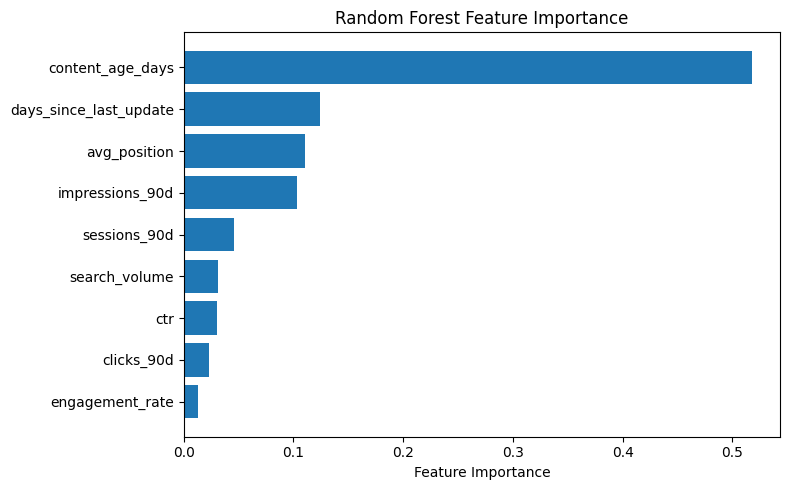

In [14]:
import matplotlib.pyplot as plt
import os

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

os.makedirs("work/figures", exist_ok=True)

plt.figure(figsize=(8,5))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    "work/figures/feature_importance.png",
    dpi=300
)

plt.show()

In [15]:
import json

metrics = {
    "random_split": {
        "MAE": 0.0569,
        "RMSE": 0.0726,
        "R2": 0.6447
    },
    "grouped_split": {
        "MAE": 0.0734,
        "RMSE": 0.0888,
        "R2": 0.5579
    }
}

os.makedirs("work/outputs", exist_ok=True)

with open("work/outputs/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Metrics exported.")

Metrics exported.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.